# Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder ,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [2]:
data=pd.read_csv("/kaggle/input/datasets/shivam2503/diamonds/diamonds.csv")

In [3]:
data.head(7)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47


In [4]:
data= data.drop(columns=['Unnamed: 0'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [6]:
data.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

# preprocessing

Text(0, 0.5, 'price')

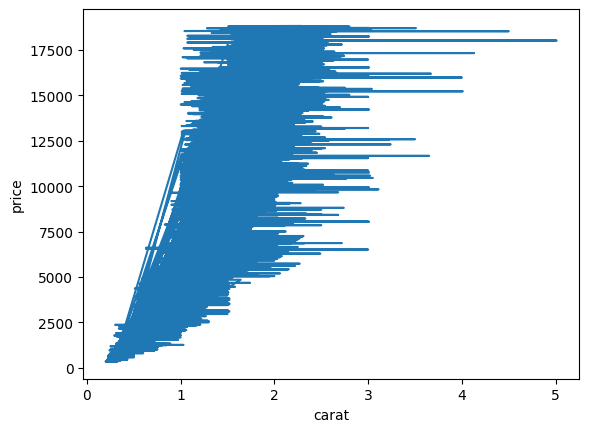

In [7]:
plt.plot("carat", "price", data=data)
plt.xlabel("carat")
plt.ylabel("price")

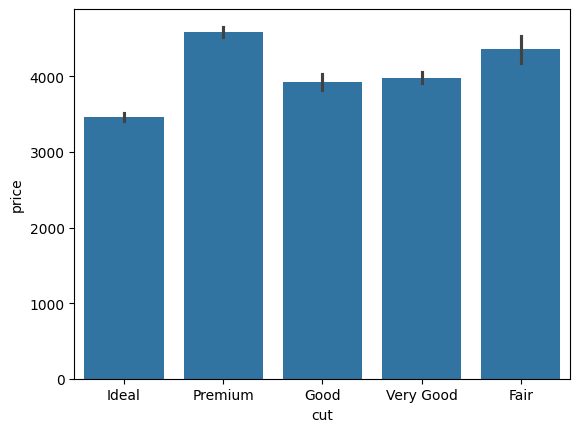

In [8]:
sns.barplot(x="cut", y="price", data=data)
plt.show()

In [9]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] 
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']




In [10]:
 oe=OrdinalEncoder(categories=[cut_order, color_order, clarity_order])


In [11]:
columns_to_encode = ["cut", "color", "clarity"]
data[columns_to_encode] = oe.fit_transform(data[columns_to_encode])

In [12]:
data.head(1)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43


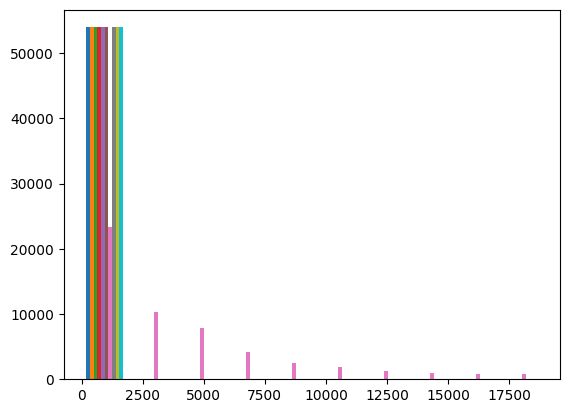

In [13]:
plt.hist(data)
plt.show()

In [14]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


In [15]:
y=data["price"]

In [16]:
x=data.drop("price",axis=1)

In [17]:
x.sample(3)

,carat,cut,color,clarity,depth,table,x,y,z
41637,0.32,3.0,0.0,3.0,61.9,58.0,4.38,4.35,2.70
46748,0.51,2.0,3.0,6.0,62.9,57.0,5.08,5.12,3.21
1258,0.70,4.0,2.0,6.0,60.5,58.0,5.76,5.81,3.50


In [18]:
ss=StandardScaler()

In [19]:
x_scaled=ss.fit_transform(x)

In [20]:
x_scaled

array([[-1.19816781,  0.98147332,  0.93716275, ..., -1.58783745,
        -1.53619556, -1.57112919],
       [-1.24036129,  0.08588908,  0.93716275, ..., -1.64132529,
        -1.65877419, -1.74117497],
       [-1.19816781, -1.70527938,  0.93716275, ..., -1.49869105,
        -1.45739502, -1.74117497],
       ...,
       [-0.20662095, -0.80969515,  1.52502147, ..., -0.06343409,
        -0.04774083,  0.03013526],
       [ 0.13092691,  0.08588908, -0.8264134 , ...,  0.37338325,
         0.33750627,  0.28520393],
       [-0.10113725,  0.98147332,  1.52502147, ...,  0.08811478,
         0.11861587,  0.14349912]])

In [21]:
x_train, x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42,test_size=0.2)

# Model 

In [22]:
lr=LinearRegression()

In [23]:
lr.fit(x_train,y_train)

LinearRegression()

In [24]:
y_pred=lr.predict(x_test)

In [25]:
rmse =root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error of Linear Regression: {rmse}")

Root Mean Squared Error of Linear Regression: 1224.5965418579535


# SVR

In [26]:
svr=SVR()

In [27]:
svr.fit(x_train,y_train)

SVR()

In [28]:
svr_pred=svr.predict(x_test)

In [29]:
rmse =root_mean_squared_error(y_test, svr_pred)
print(f"Root Mean Squared Error of SVR: {rmse}")

Root Mean Squared Error of SVR: 2719.084771475406


# DecisionTreeRegressor

In [30]:
DT=DecisionTreeRegressor(max_depth=5)

In [31]:
DT.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=5)

In [32]:
dt_pred=DT.predict(x_test)

In [33]:
rmse =root_mean_squared_error(y_test, dt_pred)
print(f"Root Mean Squared Error of Decision tree: {rmse}")

Root Mean Squared Error of Decision tree: 986.0977998690706


In [34]:
rf=RandomForestRegressor(n_estimators=100,
    random_state=42,
    oob_score=True)

In [35]:
rf.fit(x_train,y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [36]:
rf_pred=rf.predict(x_test)

In [37]:
rmse =root_mean_squared_error(y_test, rf_pred)
print(f"Root Mean Squared Error of Random Forest: {rmse}")

Root Mean Squared Error of Random Forest: 540.9949656290182


# Important Feature

In [38]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

   Feature  Importance
0    carat    0.615851
7        y    0.272547
3  clarity    0.062980
2    color    0.031078
6        x    0.005188
8        z    0.005088
4    depth    0.003159
5    table    0.002281
1      cut    0.001828


In [39]:

r2 = r2_score(y_test, rf_pred)
print(f"Model Accuracy (R-squared): {r2 * 100:.2f}%")

Model Accuracy (R-squared): 98.16%
